# Actividad Opcional 3: EDA Completo con Heart Disease Dataset

Este notebook realiza un Análisis Exploratorio de Datos (EDA) completo del dataset **Heart Disease** de UCI (id=45), incluyendo:
- Análisis de datos faltantes con `missingno`
- Estadística descriptiva completa
- Detección de outliers
- Análisis de correlaciones
- Cálculo de entropía para variables categóricas

**Dataset**: Heart Disease (UCI id=45)
**Fuentes**: Cleveland, Hungary, Switzerland, Long Beach VA

## Objetivo

Realizar un EDA completo y profesional que incluya:
1. Carga del dataset completo (4 bases de datos)
2. Análisis de datos faltantes con visualizaciones
3. Estadística descriptiva de variables numéricas y categóricas
4. Detección y análisis de outliers
5. Análisis de correlaciones y relaciones entre variables
6. Cálculo de entropía de Shannon para variables categóricas

## Variables del Dataset

| Variable   | Descripción |
| ---------- | --------------------------------------------------------------------- |
| `age`      | Edad del paciente (en años) |
| `sex`      | Sexo (1 = masculino, 0 = femenino) |
| `cp`       | Tipo de dolor de pecho (1, 2, 3, 4) |
| `trestbps` | Presión arterial en reposo (mm Hg) |
| `chol`     | Colesterol sérico (mg/dl) |
| `fbs`      | Glucemia en ayunas > 120 mg/dl (1 = sí, 0 = no) |
| `restecg`  | Resultados electrocardiográficos en reposo (0, 1, 2) |
| `thalach`  | Frecuencia cardíaca máxima alcanzada |
| `exang`    | Angina inducida por ejercicio (1 = sí, 0 = no) |
| `oldpeak`  | Depresión del ST inducida por ejercicio |
| `slope`    | Pendiente del segmento ST (1, 2, 3) |
| `ca`       | Número de vasos principales coloreados por fluoroscopía (0-3) |
| `thal`     | Resultado del test de talio (3, 6, 7) |
| `num`      | Diagnóstico de enfermedad cardíaca (0 = sin, 1-4 = severidad) |

## 1. Librerías y carga de datos

Primero importamos las librerías de trabajo y cargamos el dataset completo usando `ucimlrepo`.

In [1]:
import pandas as pd
import numpy as np
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st
from scipy.stats import entropy

sns.set_theme(style="whitegrid", palette="deep")

# ============================================================
# Cargamos el dataset COMPLETO de las 4 bases de datos
# (Cleveland, Hungary, Switzerland y Long Beach VA) desde los
# archivos 'processed.*.data' del zip local.
# Nota: ucimlrepo solo expone la base de Cleveland, por eso
# cargamos las 4 bases manualmente para tener el dataset completo.
# ============================================================

columnas = ["age", "sex", "cp", "trestbps", "chol", "fbs",
            "restecg", "thalach", "exang", "oldpeak", "slope",
            "ca", "thal", "num"]

archivos = {
    "cleveland":    "../dataset_tp/processed.cleveland.data",
    "hungary":      "../dataset_tp/processed.hungarian.data",
    "switzerland":  "../dataset_tp/processed.switzerland.data",
    "long_beach_va": "../dataset_tp/processed.va.data",
}

listas_dfs = []
for fuente, ruta in archivos.items():
    tmp = pd.read_csv(ruta, names=columnas, na_values=["?"])
    tmp["source"] = fuente
    listas_dfs.append(tmp)
    print(f"Base {fuente}: {len(tmp)} registros")

df = pd.concat(listas_dfs, ignore_index=True)
print(f"\nDataset completo: {len(df)} registros en total")
df.head()

Base cleveland: 303 registros
Base hungary: 294 registros
Base switzerland: 123 registros
Base long_beach_va: 200 registros

Dataset completo: 920 registros en total


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,source
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0,cleveland
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2,cleveland
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1,cleveland
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0,cleveland
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0,cleveland


## 2b. Tratamiento de ceros inválidos

En el dataset hay variables **continuas o de código** donde un valor de `0` no tiene sentido físico y, por lo tanto, se trata de un error de registro:

- `chol` (colesterol sérico): un valor de `0` mg/dl es imposible.
- `trestbps` (presión arterial en reposo): una presión de `0` mmHg es imposible.

En cambio, variables como `fbs`, `exang`, `restecg` o `ca` **sí pueden valer `0`** de forma legítima (indican "no", "ausencia" o "0 vasos afectados").

Por eso, aplicamos la **Opción A**: convertimos únicamente los ceros de `chol` y `trestbps` a `NaN`, para que no distorsionen las medidas de tendencia central ni la detección de outliers.


In [2]:
# Convertimos los ceros inválidos de chol y trestbps a NaN
for col in ["chol", "trestbps"]:
    n_ceros = (df[col] == 0).sum()
    df[col] = df[col].replace(0, np.nan)
    print(f"{col}: {n_ceros} ceros inválidos convertidos a NaN")

print()
print("Nulos después del tratamiento:")
print(df[["chol", "trestbps"]].isna().sum())


chol: 172 ceros inválidos convertidos a NaN
trestbps: 1 ceros inválidos convertidos a NaN

Nulos después del tratamiento:
chol        202
trestbps     60
dtype: int64


> **Nota sobre `ca`:** los valores `0` de `ca` son válidos (0 = ningún vaso afectado). Los 611 faltantes son `?` leídos como `NaN`, no ceros. Es decir, ceros y faltantes son categorías mutuamente excluyentes y **no** deben convertirse.


## 2. Vista general del dataset

Revisamos cuántas filas y columnas tiene, qué tipos de variables hay y si existen valores faltantes o duplicados.

In [3]:
print(f"Filas y columnas: {df.shape}")
df.info()

Filas y columnas: (920, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       920 non-null    float64
 1   sex       920 non-null    float64
 2   cp        920 non-null    float64
 3   trestbps  860 non-null    float64
 4   chol      718 non-null    float64
 5   fbs       830 non-null    float64
 6   restecg   918 non-null    float64
 7   thalach   865 non-null    float64
 8   exang     865 non-null    float64
 9   oldpeak   858 non-null    float64
 10  slope     611 non-null    float64
 11  ca        309 non-null    float64
 12  thal      434 non-null    float64
 13  num       920 non-null    int64  
 14  source    920 non-null    object 
dtypes: float64(13), int64(1), object(1)
memory usage: 107.9+ KB


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,920.0,53.510870,9.424685,28.0,47.0,54.0,60.00,77.0
sex,920.0,0.789130,0.408148,0.0,1.0,1.0,1.00,1.0
cp,920.0,3.250000,0.930969,1.0,3.0,4.0,4.00,4.0
trestbps,860.0,132.286047,18.536175,80.0,120.0,130.0,140.00,200.0
chol,718.0,246.832869,58.527062,85.0,210.0,239.5,276.75,603.0
fbs,830.0,0.166265,0.372543,0.0,0.0,0.0,0.00,1.0
restecg,918.0,0.604575,0.805827,0.0,0.0,0.0,1.00,2.0
thalach,865.0,137.545665,25.926276,60.0,120.0,140.0,157.00,202.0
exang,865.0,0.389595,0.487941,0.0,0.0,0.0,1.00,1.0
oldpeak,858.0,0.878788,1.091226,-2.6,0.0,0.5,1.50,6.2


## 3. Análisis de datos faltantes

Utilizamos la librería `missingno` para visualizar los patrones de datos faltantes en el dataset.

<Figure size 1200x600 with 0 Axes>

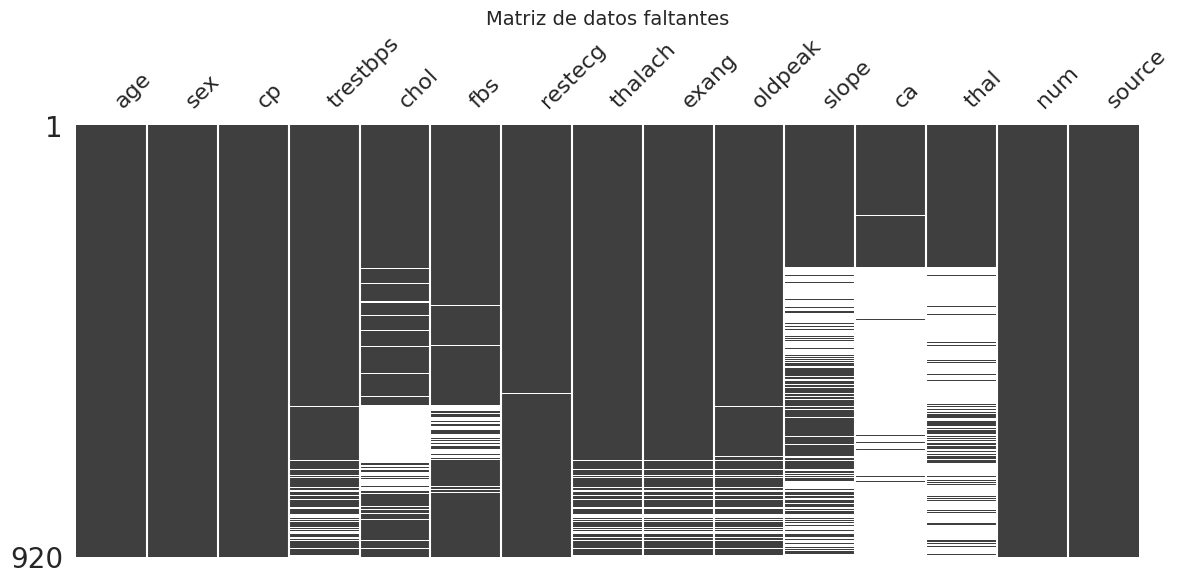

In [5]:
# Matriz de datos faltantes
plt.figure(figsize=(12, 6))
msno.matrix(df, sparkline=False, figsize=(12, 6))
plt.title('Matriz de datos faltantes', fontsize=14)
plt.tight_layout()
plt.show()

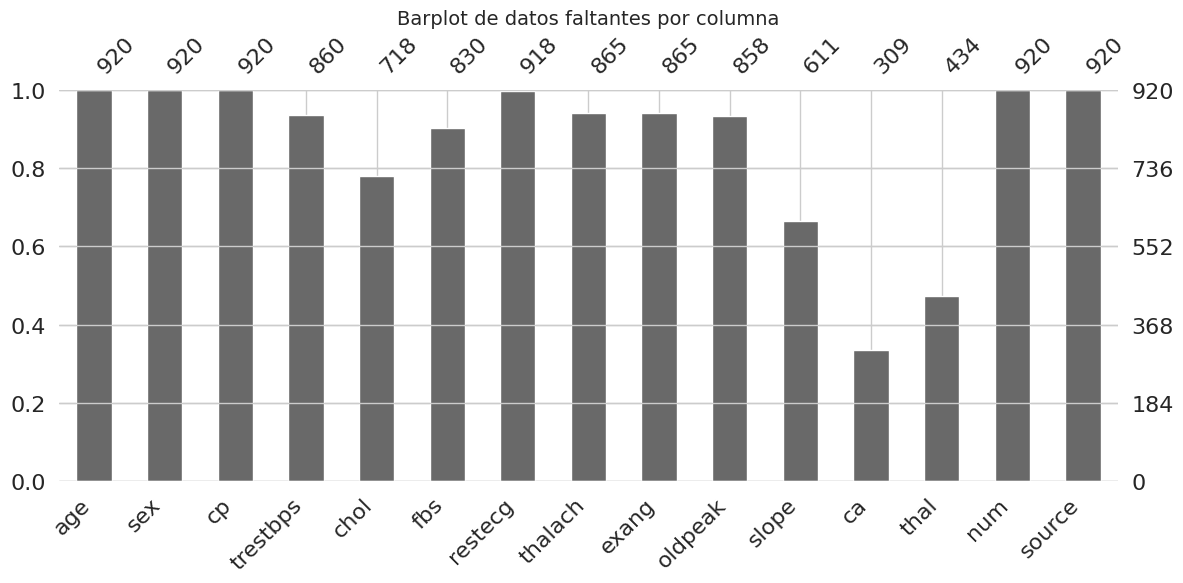

In [6]:
# Barplot de datos faltantes
plt.figure(figsize=(12, 6))
msno.bar(df, figsize=(12, 6))
plt.title('Barplot de datos faltantes por columna', fontsize=14)
plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

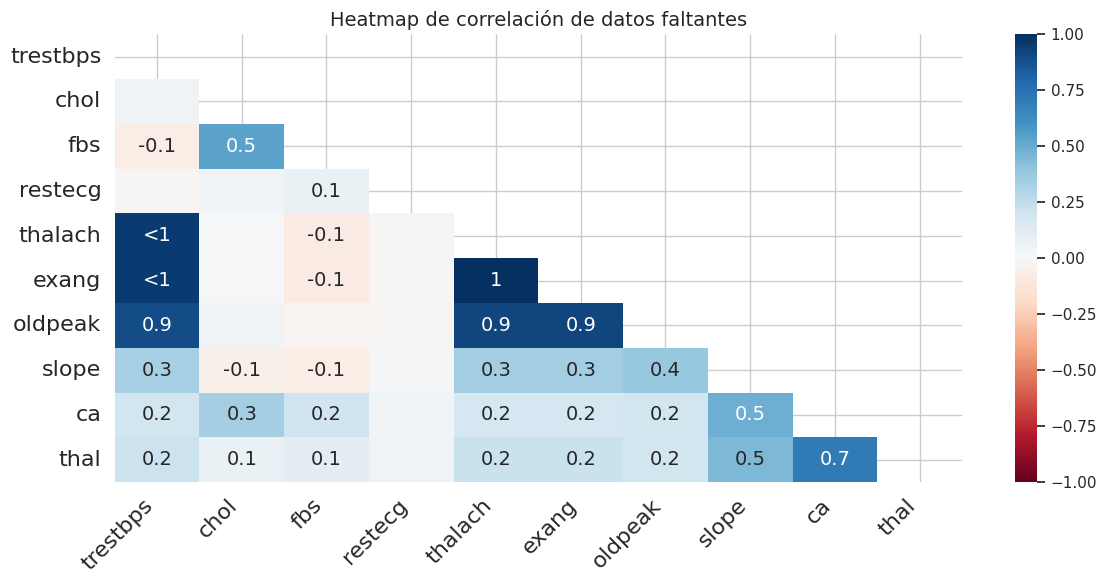

In [7]:
# Heatmap de correlación de datos faltantes
plt.figure(figsize=(12, 6))
msno.heatmap(df, figsize=(12, 6))
plt.title('Heatmap de correlación de datos faltantes', fontsize=14)
plt.tight_layout()
plt.show()

In [8]:
# Resumen de datos faltantes
missing = pd.DataFrame({
    "nulos": df.isna().sum(),
    "porcentaje": (df.isna().mean() * 100).round(2)
})

print("Columns con datos faltantes:")
print(missing[missing["nulos"] > 0].sort_values("porcentaje", ascending=False))
print(f"\nTotal de filas con al menos un nulo: {df.isna().any(axis=1).sum()}")
print(f"Porcentaje de filas con nulos: {(df.isna().any(axis=1).mean() * 100).round(2)}%")

Columns con datos faltantes:
          nulos  porcentaje
ca          611       66.41
thal        486       52.83
slope       309       33.59
chol        202       21.96
fbs          90        9.78
oldpeak      62        6.74
trestbps     60        6.52
thalach      55        5.98
exang        55        5.98
restecg       2        0.22

Total de filas con al menos un nulo: 621
Porcentaje de filas con nulos: 67.5%


### Análisis de datos faltantes por grupo (base de origen)

Como el dataset está formado por 4 bases distintas, verificamos si la ausencia de datos se concentra en alguna base en particular. Esto nos permite clasificar el **mecanismo de ausencia** (MCAR, MAR o MNAR) siguiendo el enfoque de clase.


In [9]:
from IPython.display import display

def nulos_por_grupo(dataframe, grupo_cols, target_col):
    """Devuelve el % de nulos de las variables seleccionadas agrupado por una columna."""
    resultado = dataframe.groupby(grupo_cols).apply(
        lambda x: round(x[target_col].isna().mean() * 100, 2)
    ).reset_index()
    return resultado

cols_con_nulos = ["trestbps", "chol", "fbs", "restecg", "thalach",
                  "exang", "oldpeak", "slope", "ca", "thal"]

print("Porcentaje de nulos por base de origen:")
display(nulos_por_grupo(df, ["source"], cols_con_nulos))


Porcentaje de nulos por base de origen:


/tmp/ipykernel_5928/3742707423.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  resultado = dataframe.groupby(grupo_cols).apply(


,source,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,cleveland,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.32,0.66
1,hungary,0.34,7.82,2.72,0.34,0.34,0.34,0.00,64.63,98.98,90.48
2,long_beach_va,28.50,28.00,3.50,0.00,26.50,26.50,28.00,51.00,99.00,83.00
3,switzerland,1.63,100.00,60.98,0.81,0.81,0.81,4.88,13.82,95.93,42.28


In [10]:
# Nulos de ca y thal por base (las dos más críticas)
resumen_faltantes = df.groupby("source")[["ca", "thal", "slope"]].apply(
    lambda x: round(x.isna().mean() * 100, 2)
)
print(resumen_faltantes)


                  ca   thal  slope
source                            
cleveland       1.32   0.66   0.00
hungary        98.98  90.48  64.63
long_beach_va  99.00  83.00  51.00
switzerland    95.93  42.28  13.82


### Conclusión sobre el mecanismo de ausencia

La ausencia de datos **no es aleatoria (no es MCAR)**, sino que está condicionada a la variable `source` (base de origen):

- `ca` falta en el **~99% de Hungary**, ~96% de Switzerland y ~99% de Long Beach VA, pero solo en el 1% de Cleveland.
- `thal` y `slope` siguen el mismo patrón.

Como la probabilidad de que un valor falte depende de **otras variables observadas** (la base de origen), clasificamos el mecanismo como **MAR (Missing At Random)**.

**Decisión (Opción A):** para un EDA descriptivo **no imputamos** los valores faltantes (imputar `ca`/`thal`, con 66% y 53% de nulos, sesgaría el análisis). Los dejamos como `NaN`, los documentamos y trabajamos con las filas completas de cada variable cuando es necesario.


## 4. Clasificación de variables

In [11]:
categorical_cols = ["sex", "cp", "fbs", "restecg", "exang", "slope", "thal"]
df["target"] = df["num"].apply(lambda value: "Con enfermedad" if value > 0 else "Sin enfermedad")

tipos = pd.DataFrame({
    "tipo": df.dtypes.astype(str),
    "nulos": df.isna().sum(),
    "porcentaje_nulos": (df.isna().mean() * 100).round(2),
})

duplicados = df.duplicated().sum()
print(f"Cantidad de duplicados: {duplicados}")
tipos

Cantidad de duplicados: 2


,tipo,nulos,porcentaje_nulos
age,float64,0,0.00
sex,float64,0,0.00
cp,float64,0,0.00
trestbps,float64,60,6.52
chol,float64,202,21.96
fbs,float64,90,9.78
restecg,float64,2,0.22
thalach,float64,55,5.98
exang,float64,55,5.98
oldpeak,float64,62,6.74


In [12]:
numericas = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']
cat_nominales = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']

print("Variables numericas:", numericas)
print("Variables categoricas nominales:", cat_nominales)
print("Variable objetivo: target (categorica nominal)")

Variables numericas: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']
Variables categoricas nominales: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']
Variable objetivo: target (categorica nominal)


### Funciones auxiliares (helper functions)

In [13]:
def plot_histograma(data, column, figsize=(6, 3), bins=15, kde=True, mvd=True, shade=True, snk=False):
    skewness = (data[column]).skew()
    kurtosis_val = (data[column]).kurt()
    media = (data[column]).mean()
    var = (data[column]).var()
    std = (data[column]).std()
    plt.figure(figsize=figsize)
    plt.grid(axis='y')
    sns.histplot(data[column], bins=bins, kde=kde)
    if snk:
        plt.figtext(0.7, 0.8, f'Asimetria: {skewness:.2f}', fontsize=10, color='blue')
        plt.figtext(0.715, 0.73, f'Curtosis: {kurtosis_val:.2f}', fontsize=10, color='blue')
        plt.axvline(media, color='red', linestyle='--', label='Media')
    if mvd and shade:
        plt.axvspan(media - std, media + std, alpha=0.1, color='orange', label='+-1 Std')
        plt.axvline(media + std, color='orange', linestyle=':', label='+1 Std')
        plt.axvline(media - std, color='orange', linestyle=':', label='-1 Std')
        plt.figtext(0.15, 0.80, f'Media: {media:.2f}', fontsize=10, color='red')
        plt.figtext(0.15, 0.73, f'Var:   {var:.2f}',   fontsize=10, color='red')
        plt.figtext(0.15, 0.66, f'Std:   {std:.2f}',   fontsize=10, color='orange')
    plt.title(f'Variable: {column}')
    plt.xlabel(f'{column}')
    plt.ylabel('Frecuencia')
    plt.show()

In [14]:
def cuartiles(variable):
    Q1 = variable.quantile(0.25)
    Q2 = variable.quantile(0.50)
    Q3 = variable.quantile(0.75)
    return Q1, Q2, Q3

In [15]:
def print_categorias(dataframe, columna):
    print(f"Cantidad de categorias que tiene la variable '{columna}': {dataframe[columna].nunique()}\n")
    print(f"Nombres de categorias presentes en la variable '{columna}': {dataframe[columna].unique()}\n")
    freq = dataframe[columna].value_counts()
    freq_rel = dataframe[columna].value_counts(normalize=True).mul(100).round(2)
    freq_tabla = pd.DataFrame({'Frecuencia absoluta': freq, 'Frecuencia relativa (%)': freq_rel})
    print(f"Frecuencias de cada categoria en la variable '{columna}':\n{freq_tabla}\n")

In [16]:
def plot_pie(data, column, ax=None, startangle=90, palette='pastel', title=None):
    counts = data[column].value_counts()
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 3))
    ax.pie(
        counts,
        labels=counts.index,
        autopct='%1.1f%%',
        startangle=startangle,
        colors=sns.color_palette(palette)
    )
    ax.set_title(title if title else f'Distribucion de "{column}"')
    ax.axis('equal')

In [17]:
def plot_violin_box(data, num_col, cat_col, figsize=(12, 4), palette='pastel', title=None):
    fig, axes = plt.subplots(1, 2, figsize=figsize, sharey=True)
    sns.violinplot(data=data, x=cat_col, y=num_col, hue=cat_col,
                   palette=palette, ax=axes[0], legend=False)
    axes[0].set_title(f'Violin: {num_col} vs. {cat_col}')
    axes[0].grid(axis='y', ls='--')
    sns.boxplot(data=data, x=cat_col, y=num_col, hue=cat_col,
                palette=palette, ax=axes[1], legend=False)
    axes[1].set_title(f'Boxplot: {num_col} vs. {cat_col}')
    axes[1].grid(axis='y', ls='--')
    plt.suptitle(title if title else f'{num_col} vs {cat_col}', fontsize=13)
    plt.tight_layout()
    plt.show()

## 5. Estadística descriptiva de variables numéricas

### Medidas de tendencia central: media, mediana y moda

In [18]:
for col in numericas:
    media = df[col].mean()
    mediana = df[col].median()
    moda = df[col].mode()[0]
    print(f"Variable: {col}")
    print(f"  Media:   {media:.2f}")
    print(f"  Mediana: {mediana:.2f}")
    print(f"  Moda:    {moda:.2f}\n")

Variable: age
  Media:   53.51
  Mediana: 54.00
  Moda:    54.00

Variable: trestbps
  Media:   132.29
  Mediana: 130.00
  Moda:    120.00

Variable: chol
  Media:   246.83
  Mediana: 239.50
  Moda:    220.00

Variable: thalach
  Media:   137.55
  Mediana: 140.00
  Moda:    150.00

Variable: oldpeak
  Media:   0.88
  Mediana: 0.50
  Moda:    0.00

Variable: ca
  Media:   0.68
  Mediana: 0.00
  Moda:    0.00



### Medidas de dispersión: varianza y desviación estándar

In [19]:
for col in numericas:
    media = df[col].mean()
    var = df[col].var()
    std = df[col].std()
    print(f"Variable: {col}")
    print(f"  Media: {media:.2f}, Varianza: {var:.2f}, Desv. Estandar: {std:.2f}\n")

Variable: age
  Media: 53.51, Varianza: 88.82, Desv. Estandar: 9.42

Variable: trestbps
  Media: 132.29, Varianza: 343.59, Desv. Estandar: 18.54

Variable: chol
  Media: 246.83, Varianza: 3425.42, Desv. Estandar: 58.53

Variable: thalach
  Media: 137.55, Varianza: 672.17, Desv. Estandar: 25.93

Variable: oldpeak
  Media: 0.88, Varianza: 1.19, Desv. Estandar: 1.09

Variable: ca
  Media: 0.68, Varianza: 0.88, Desv. Estandar: 0.94



### Cuartiles y rango intercuartil

In [20]:
for col in numericas:
    Q1, Q2, Q3 = cuartiles(df[col])
    IQR = Q3 - Q1
    print(f"Variable: {col}")
    print(f"  Q1 (25%): {Q1:.2f}")
    print(f"  Q2 (Mediana, 50%): {Q2:.2f}")
    print(f"  Q3 (75%): {Q3:.2f}")
    print(f"  IQR: {IQR:.2f}\n")

Variable: age
  Q1 (25%): 47.00
  Q2 (Mediana, 50%): 54.00
  Q3 (75%): 60.00
  IQR: 13.00

Variable: trestbps
  Q1 (25%): 120.00
  Q2 (Mediana, 50%): 130.00
  Q3 (75%): 140.00
  IQR: 20.00

Variable: chol
  Q1 (25%): 210.00
  Q2 (Mediana, 50%): 239.50
  Q3 (75%): 276.75
  IQR: 66.75

Variable: thalach
  Q1 (25%): 120.00
  Q2 (Mediana, 50%): 140.00
  Q3 (75%): 157.00
  IQR: 37.00

Variable: oldpeak
  Q1 (25%): 0.00
  Q2 (Mediana, 50%): 0.50
  Q3 (75%): 1.50
  IQR: 1.50

Variable: ca
  Q1 (25%): 0.00
  Q2 (Mediana, 50%): 0.00
  Q3 (75%): 1.00
  IQR: 1.00



### Medidas de forma: asimetría (skewness) y curtosis

In [21]:
for col in numericas:
    skew = df[col].skew()
    kurt = df[col].kurtosis()
    print(f"Variable: {col}")
    print(f"  Asimetria (skewness): {skew:.4f}")
    print(f"  Curtosis: {kurt:.4f}\n")

Variable: age
  Asimetria (skewness): -0.1960
  Curtosis: -0.3829

Variable: trestbps
  Asimetria (skewness): 0.6302
  Curtosis: 0.6306

Variable: chol
  Asimetria (skewness): 1.3149
  Curtosis: 4.7729

Variable: thalach
  Asimetria (skewness): -0.2111
  Curtosis: -0.4797

Variable: oldpeak
  Asimetria (skewness): 1.0414
  Curtosis: 1.1271

Variable: ca
  Asimetria (skewness): 1.1660
  Curtosis: 0.1995



### Histogramas con marcas de media, mediana y moda

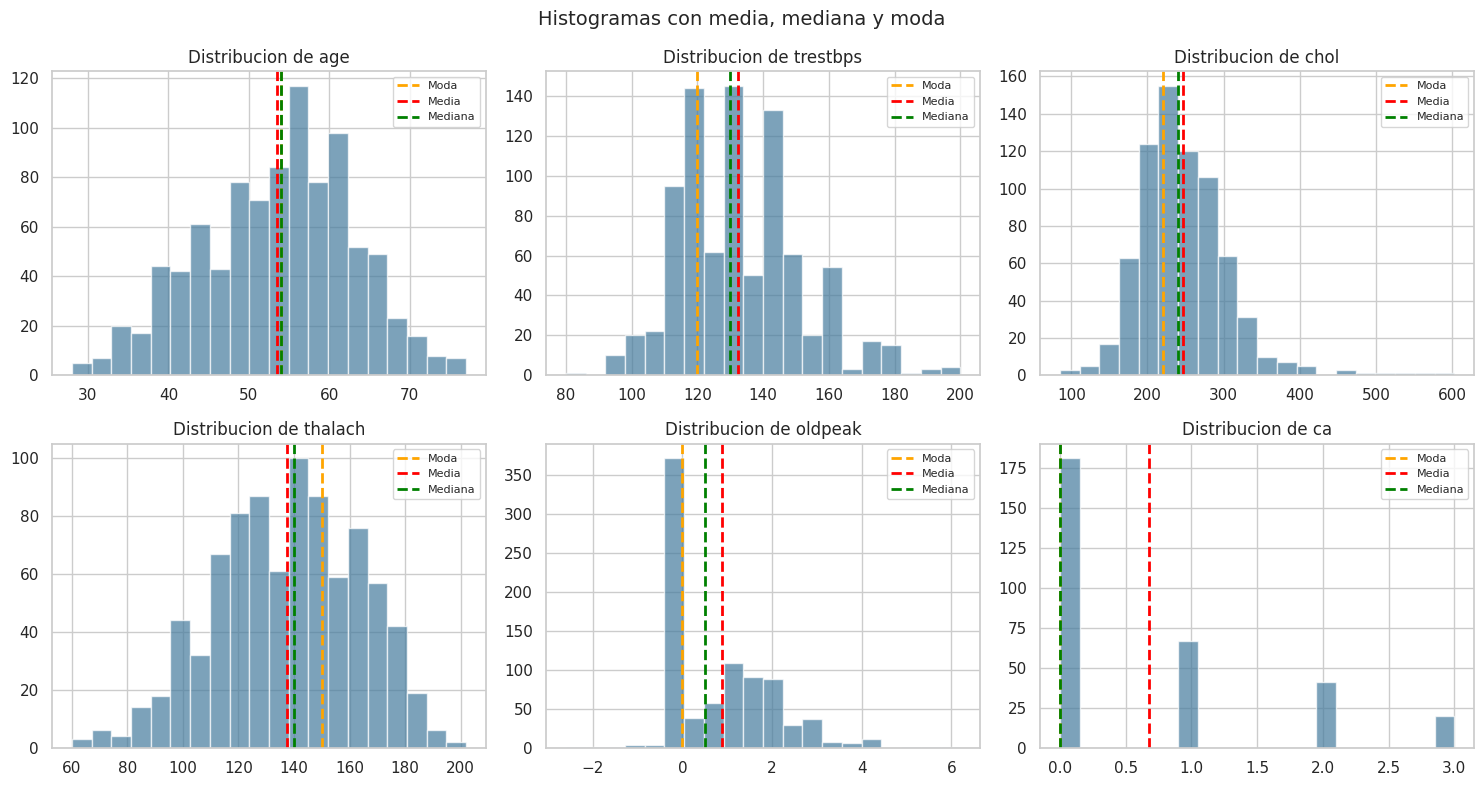

In [22]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(numericas):
    axes[i].hist(df[col].dropna(), bins=20, alpha=0.7, color='#457b9d')
    axes[i].axvline(df[col].mode()[0], color='orange', ls='--', lw=2, label='Moda')
    axes[i].axvline(df[col].mean(), color='red', ls='--', lw=2, label='Media')
    axes[i].axvline(df[col].median(), color='green', ls='--', lw=2, label='Mediana')
    axes[i].set_title(f'Distribucion de {col}')
    axes[i].legend(fontsize=8)

plt.suptitle('Histogramas con media, mediana y moda', fontsize=14)
plt.tight_layout()
plt.show()

### KDE (Kernel Density Estimation)

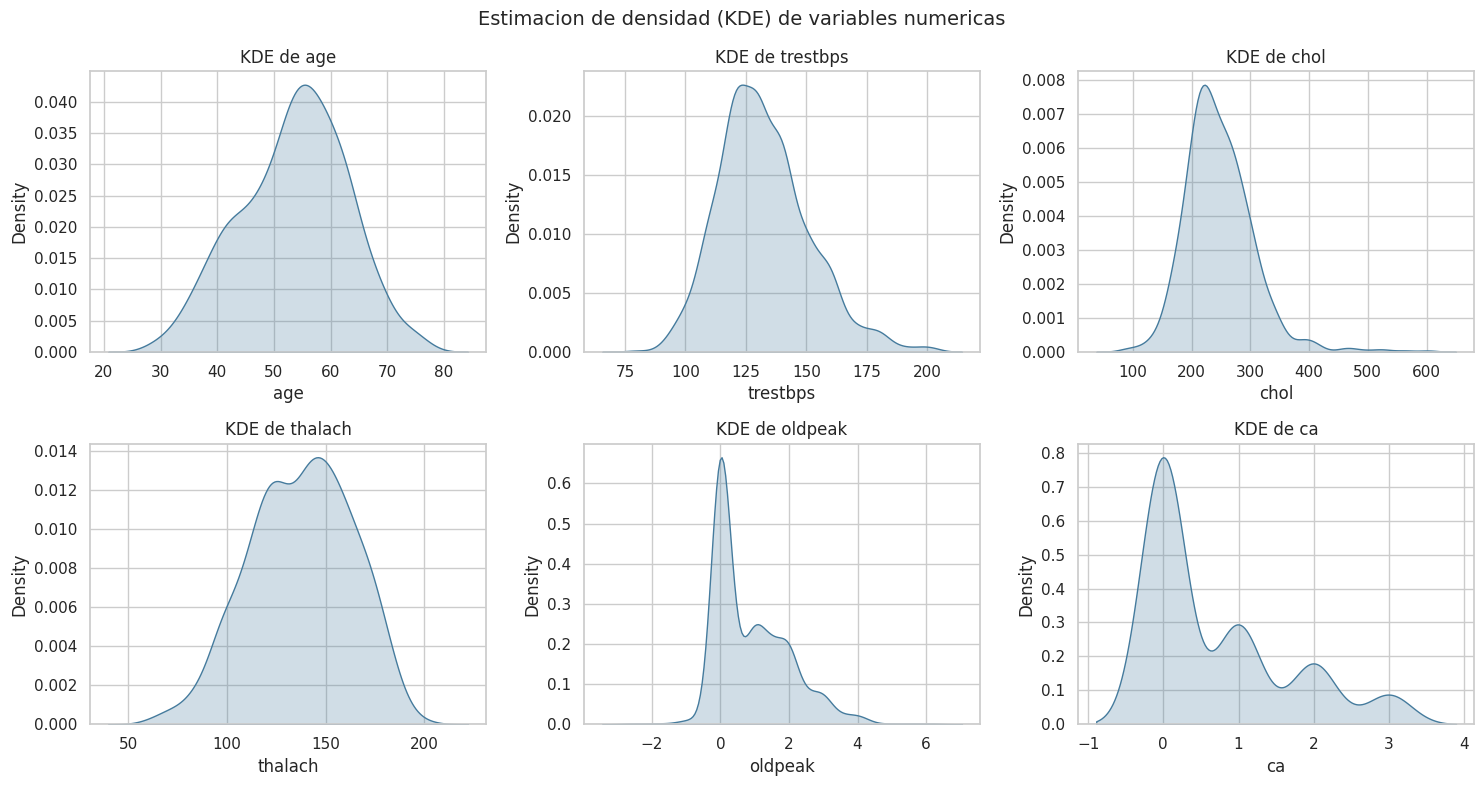

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(numericas):
    sns.kdeplot(data=df, x=col, fill=True, ax=axes[i], color='#457b9d')
    axes[i].set_title(f'KDE de {col}')

plt.suptitle('Estimacion de densidad (KDE) de variables numericas', fontsize=14)
plt.tight_layout()
plt.show()

### Boxplots con cuartiles y detección de outliers

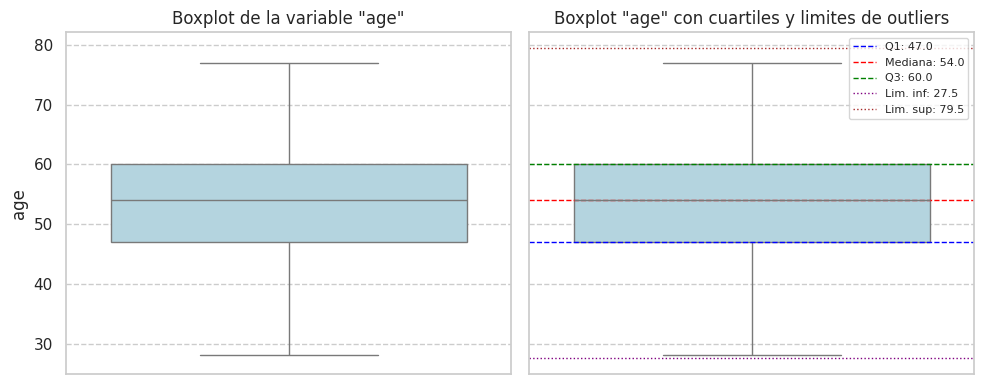

In [24]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

age = df['age'].dropna()
age_Q1, age_Q2, age_Q3 = cuartiles(df['age'])
age_IQR = age_Q3 - age_Q1
lower_limit = age_Q1 - 1.5 * age_IQR
upper_limit = age_Q3 + 1.5 * age_IQR

sns.boxplot(data=df, y='age', color='lightblue', ax=ax[0])
ax[0].set_title('Boxplot de la variable "age"')
ax[0].grid(axis='y', ls='--')

sns.boxplot(data=df, y='age', color='lightblue', ax=ax[1])
ax[1].axhline(age_Q1,      color='blue',   linestyle='--', linewidth=1, label=f'Q1: {age_Q1:.1f}')
ax[1].axhline(age_Q2,      color='red',    linestyle='--', linewidth=1, label=f'Mediana: {age_Q2:.1f}')
ax[1].axhline(age_Q3,      color='green',  linestyle='--', linewidth=1, label=f'Q3: {age_Q3:.1f}')
ax[1].axhline(lower_limit, color='purple', linestyle=':',  linewidth=1, label=f'Lim. inf: {lower_limit:.1f}')
ax[1].axhline(upper_limit, color='brown',  linestyle=':',  linewidth=1, label=f'Lim. sup: {upper_limit:.1f}')
ax[1].set_title('Boxplot "age" con cuartiles y limites de outliers')
ax[1].legend(fontsize=8)
ax[1].grid(axis='y', ls='--')

plt.tight_layout()
plt.show()

### Violinplots

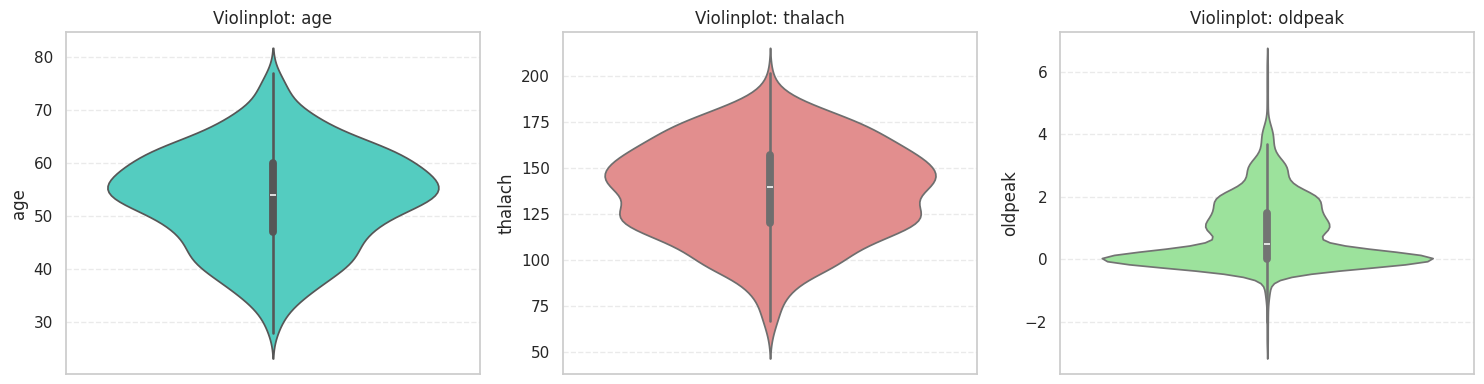

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.violinplot(data=df, y='age', color='turquoise', inner='box', ax=axes[0])
axes[0].set_title('Violinplot: age')
axes[0].grid(axis='y', ls='--', alpha=0.4)

sns.violinplot(data=df, y='thalach', color='lightcoral', inner='box', ax=axes[1])
axes[1].set_title('Violinplot: thalach')
axes[1].grid(axis='y', ls='--', alpha=0.4)

sns.violinplot(data=df, y='oldpeak', color='lightgreen', inner='box', ax=axes[2])
axes[2].set_title('Violinplot: oldpeak')
axes[2].grid(axis='y', ls='--', alpha=0.4)

plt.tight_layout()
plt.show()

## 6. Estadística descriptiva de variables categóricas

### Frecuencias absolutas y relativas

In [26]:
for col in cat_nominales:
    print_categorias(df, col)

Cantidad de categorias que tiene la variable 'sex': 2

Nombres de categorias presentes en la variable 'sex': [1. 0.]

Frecuencias de cada categoria en la variable 'sex':
     Frecuencia absoluta  Frecuencia relativa (%)
sex                                              
1.0                  726                    78.91
0.0                  194                    21.09

Cantidad de categorias que tiene la variable 'cp': 4

Nombres de categorias presentes en la variable 'cp': [1. 4. 3. 2.]

Frecuencias de cada categoria en la variable 'cp':
     Frecuencia absoluta  Frecuencia relativa (%)
cp                                               
4.0                  496                    53.91
3.0                  204                    22.17
2.0                  174                    18.91
1.0                   46                     5.00

Cantidad de categorias que tiene la variable 'fbs': 2

Nombres de categorias presentes en la variable 'fbs': [ 1.  0. nan]

Frecuencias de cada categoria e

In [27]:
print_categorias(df, 'target')

Cantidad de categorias que tiene la variable 'target': 2

Nombres de categorias presentes en la variable 'target': ['Sin enfermedad' 'Con enfermedad']

Frecuencias de cada categoria en la variable 'target':
                Frecuencia absoluta  Frecuencia relativa (%)
target                                                      
Con enfermedad                  509                    55.33
Sin enfermedad                  411                    44.67



### Entropía de Shannon para variables categóricas

La entropía mide la incertidumbre o diversidad de una variable categórica. Un valor alto indica alta diversidad de categorías.

In [28]:
for col in cat_nominales + ['target']:
    counts = df[col].value_counts()
    pi = counts / counts.sum()
    
    # Entropía máxima (si todas las categorías ocurrieran con la misma probabilidad)
    H_max = np.log2(df[col].nunique())
    
    # Entropía de Shannon con Scipy
    H_Shannon = entropy(pi, base=2)
    
    # Proporción de entropía máxima
    prop = H_Shannon / H_max if H_max > 0 else 0
    
    print(f"Variable: {col}")
    print(f"  Categorías: {df[col].nunique()}")
    print(f"  Entropía H: {H_Shannon:.4f}")
    print(f"  Entropía máxima H_max: {H_max:.4f}")
    print(f"  Proporción H/H_max: {prop:.4f}\n")

Variable: sex
  Categorías: 2
  Entropía H: 0.7431
  Entropía máxima H_max: 1.0000
  Proporción H/H_max: 0.7431

Variable: cp
  Categorías: 4
  Entropía H: 1.6329
  Entropía máxima H_max: 2.0000
  Proporción H/H_max: 0.8164

Variable: fbs
  Categorías: 2
  Entropía H: 0.6491
  Entropía máxima H_max: 1.0000
  Proporción H/H_max: 0.6491

Variable: restecg
  Categorías: 3
  Entropía H: 1.3704
  Entropía máxima H_max: 1.5850
  Proporción H/H_max: 0.8646

Variable: exang
  Categorías: 2
  Entropía H: 0.9645
  Entropía máxima H_max: 1.0000
  Proporción H/H_max: 0.9645

Variable: slope
  Categorías: 3
  Entropía H: 1.3317
  Entropía máxima H_max: 1.5850
  Proporción H/H_max: 0.8402

Variable: thal
  Categorías: 3
  Entropía H: 1.3816
  Entropía máxima H_max: 1.5850
  Proporción H/H_max: 0.8717

Variable: target
  Categorías: 2
  Entropía H: 0.9918
  Entropía máxima H_max: 1.0000
  Proporción H/H_max: 0.9918



### Gráficos de torta (pie charts)

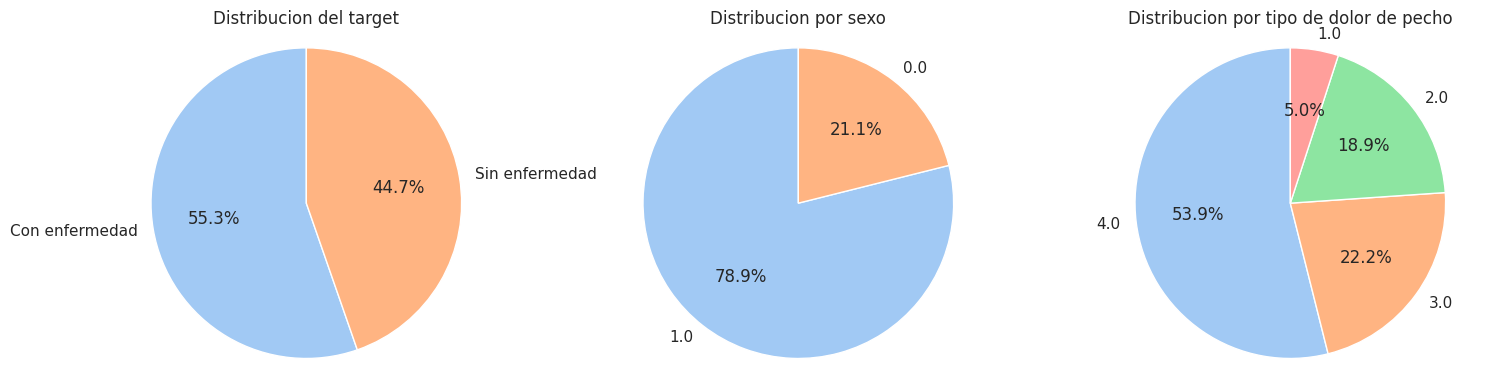

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

plot_pie(df, 'target', ax=axes[0], title='Distribucion del target')
plot_pie(df, 'sex', ax=axes[1], title='Distribucion por sexo')
plot_pie(df, 'cp', ax=axes[2], title='Distribucion por tipo de dolor de pecho')

plt.tight_layout()
plt.show()

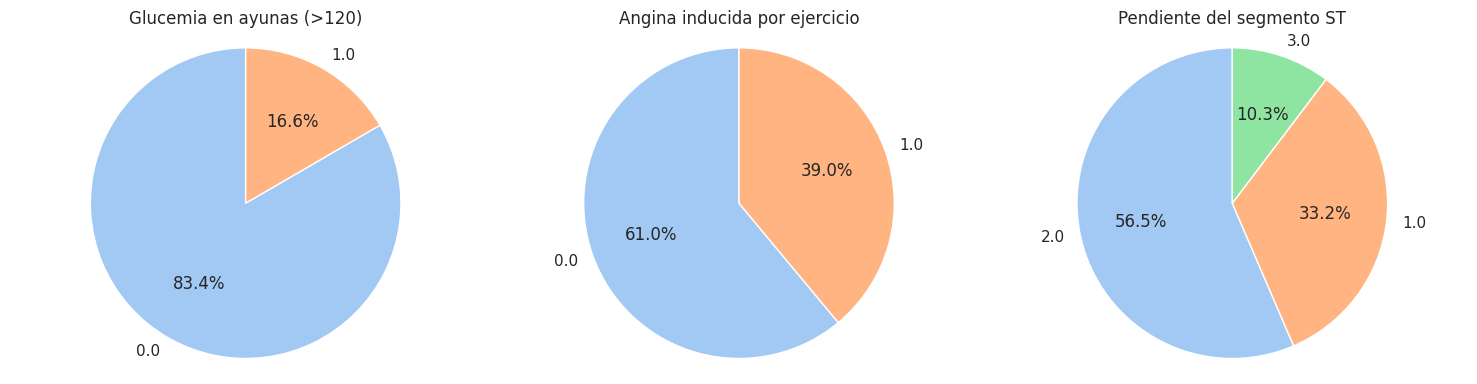

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

plot_pie(df, 'fbs', ax=axes[0], title='Glucemia en ayunas (>120)')
plot_pie(df, 'exang', ax=axes[1], title='Angina inducida por ejercicio')
plot_pie(df, 'slope', ax=axes[2], title='Pendiente del segmento ST')

plt.tight_layout()
plt.show()

### Frecuencias relativas (barras horizontales)

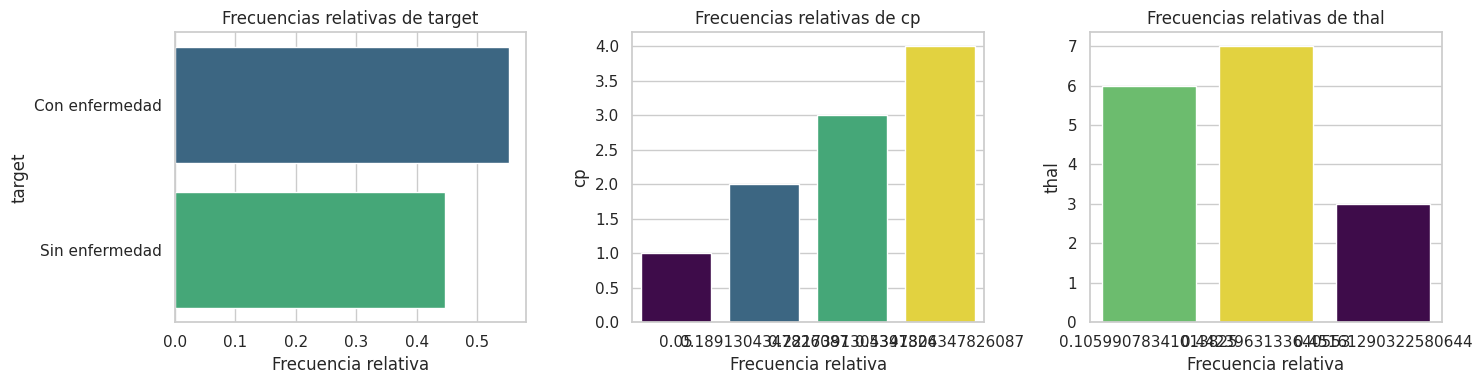

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, col in enumerate(['target', 'cp', 'thal']):
    freq_rel = df[col].value_counts(normalize=True)
    sns.barplot(x=freq_rel.values, y=freq_rel.index, hue=freq_rel.index, 
                palette='viridis', ax=axes[i], legend=False)
    axes[i].set_title(f'Frecuencias relativas de {col}')
    axes[i].set_xlabel('Frecuencia relativa')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

## 7. Análisis de outliers

### Método IQR (Interquartile Range)

In [32]:
def detect_outliers_iqr(data, column):
    """Detecta outliers usando el método IQR"""
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower) | (data[column] > upper)]
    return outliers, lower, upper

print("Análisis de outliers con método IQR:")
print("="*60)
for col in numericas:
    outliers, lower, upper = detect_outliers_iqr(df, col)
    print(f"\nVariable: {col}")
    print(f"  Límite inferior: {lower:.2f}")
    print(f"  Límite superior: {upper:.2f}")
    print(f"  Cantidad de outliers: {len(outliers)}")
    print(f"  Porcentaje de outliers: {(len(outliers)/len(df)*100):.2f}%")

Análisis de outliers con método IQR:

Variable: age
  Límite inferior: 27.50
  Límite superior: 79.50
  Cantidad de outliers: 0
  Porcentaje de outliers: 0.00%

Variable: trestbps
  Límite inferior: 90.00
  Límite superior: 170.00
  Cantidad de outliers: 27
  Porcentaje de outliers: 2.93%

Variable: chol
  Límite inferior: 109.88
  Límite superior: 376.88
  Cantidad de outliers: 23
  Porcentaje de outliers: 2.50%

Variable: thalach
  Límite inferior: 64.50
  Límite superior: 212.50
  Cantidad de outliers: 2
  Porcentaje de outliers: 0.22%

Variable: oldpeak
  Límite inferior: -2.25
  Límite superior: 3.75
  Cantidad de outliers: 16
  Porcentaje de outliers: 1.74%

Variable: ca
  Límite inferior: -1.50
  Límite superior: 2.50
  Cantidad de outliers: 20
  Porcentaje de outliers: 2.17%


### Método Z-score

In [33]:
def detect_outliers_zscore(data, column, threshold=3):
    """Detecta outliers usando el método Z-score"""
    z_scores = np.abs(st.zscore(data[column].dropna()))
    outliers = data[column].dropna()[z_scores > threshold]
    return outliers

print("Análisis de outliers con método Z-score (|z| > 3):")
print("="*60)
for col in numericas:
    outliers = detect_outliers_zscore(df, col)
    print(f"\nVariable: {col}")
    print(f"  Cantidad de outliers: {len(outliers)}")
    print(f"  Porcentaje de outliers: {(len(outliers)/len(df)*100):.2f}%")

Análisis de outliers con método Z-score (|z| > 3):

Variable: age
  Cantidad de outliers: 0
  Porcentaje de outliers: 0.00%

Variable: trestbps
  Cantidad de outliers: 7
  Porcentaje de outliers: 0.76%

Variable: chol
  Cantidad de outliers: 8
  Porcentaje de outliers: 0.87%

Variable: thalach
  Cantidad de outliers: 0
  Porcentaje de outliers: 0.00%

Variable: oldpeak
  Cantidad de outliers: 7
  Porcentaje de outliers: 0.76%

Variable: ca
  Cantidad de outliers: 0
  Porcentaje de outliers: 0.00%


## 8. Relaciones entre variables

### Matriz de correlación

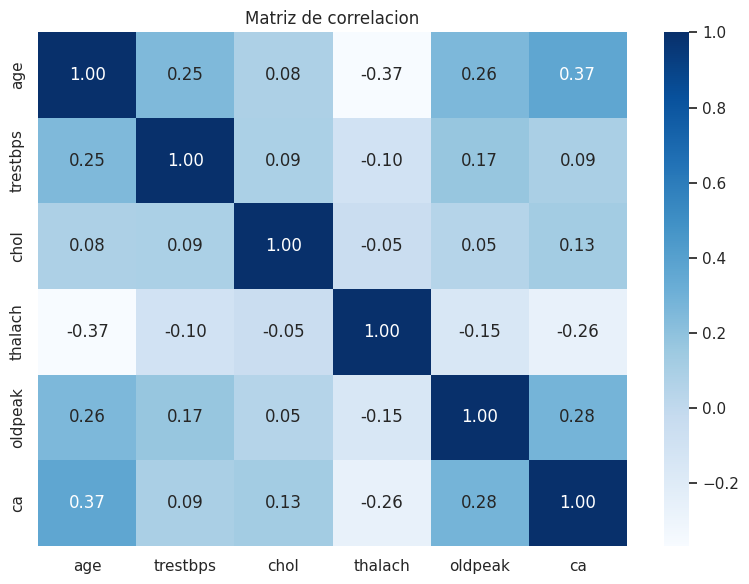

In [34]:
numeric_cols_corr = ["age", "trestbps", "chol", "thalach", "oldpeak", "ca"]
corr = df[numeric_cols_corr].corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="Blues", fmt=".2f")
plt.title("Matriz de correlacion")
plt.tight_layout()
plt.show()

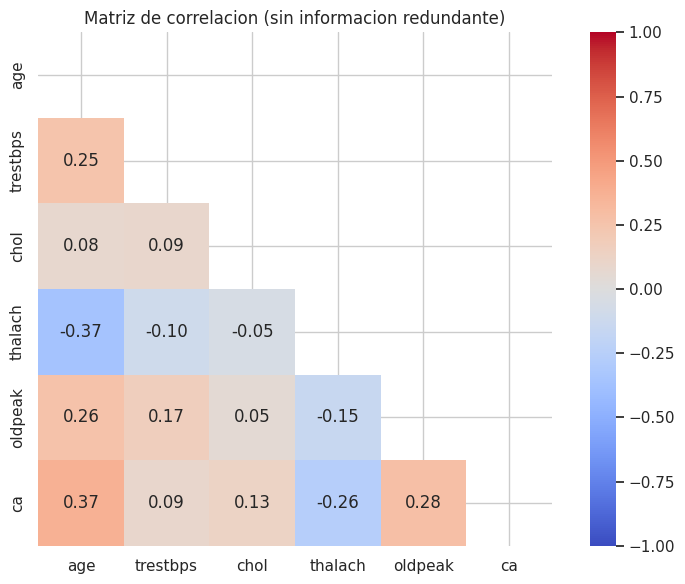

In [35]:
mascara = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, center=0, square=True, mask=mascara)
plt.title('Matriz de correlacion (sin informacion redundante)')
plt.tight_layout()
plt.show()

### Pairplot de variables numéricas

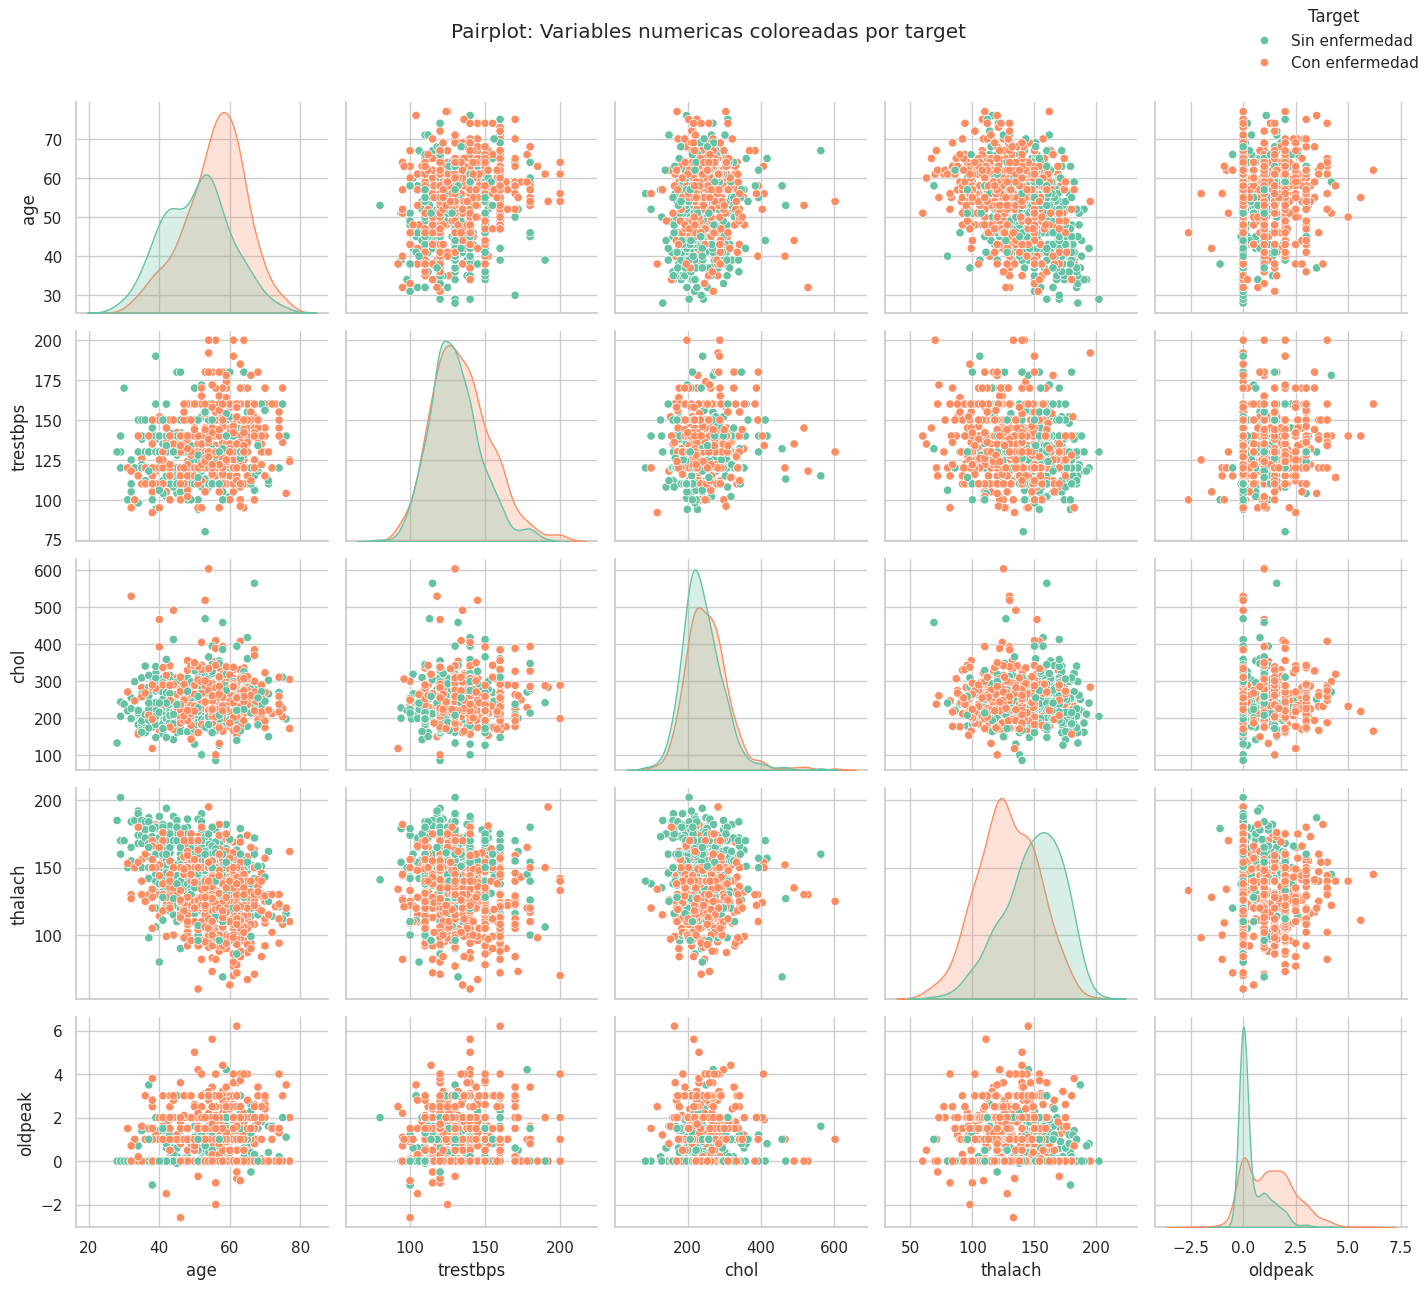

In [36]:
grafico = sns.pairplot(data=df, hue='target', palette='Set2', 
                       vars=['age', 'trestbps', 'chol', 'thalach', 'oldpeak'])
grafico.figure.suptitle('Pairplot: Variables numericas coloreadas por target', y=1.02)
grafico.legend.set_bbox_to_anchor((1, 1))
grafico.legend.set_title('Target')
plt.tight_layout()
plt.show()

### Tablas de contingencia

#### Sexo vs Target

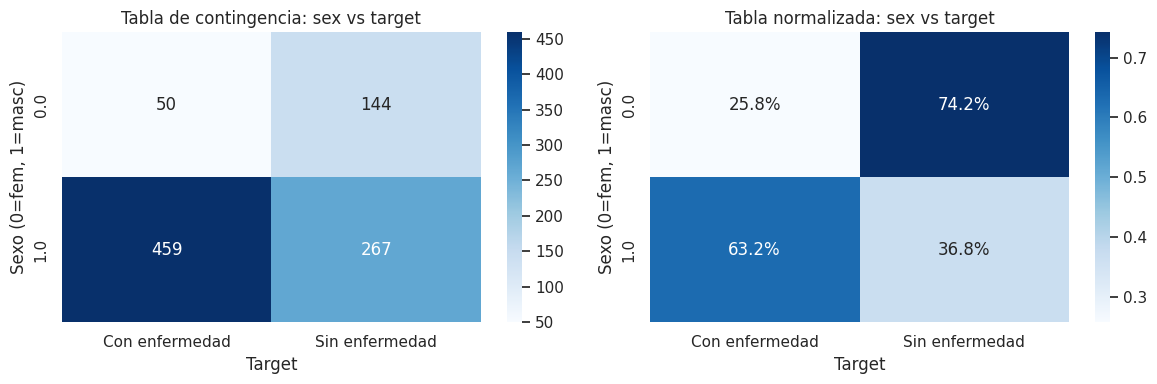

In [37]:
cross_tab = pd.crosstab(df['sex'], df['target'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.heatmap(cross_tab, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Tabla de contingencia: sex vs target')
axes[0].set_xlabel('Target')
axes[0].set_ylabel('Sexo (0=fem, 1=masc)')

cross_tab_pct = pd.crosstab(df['sex'], df['target'], normalize='index')
sns.heatmap(cross_tab_pct, annot=True, fmt='.1%', cmap='Blues', ax=axes[1])
axes[1].set_title('Tabla normalizada: sex vs target')
axes[1].set_xlabel('Target')
axes[1].set_ylabel('Sexo (0=fem, 1=masc)')

plt.tight_layout()
plt.show()

#### Tipo de dolor de pecho vs Target

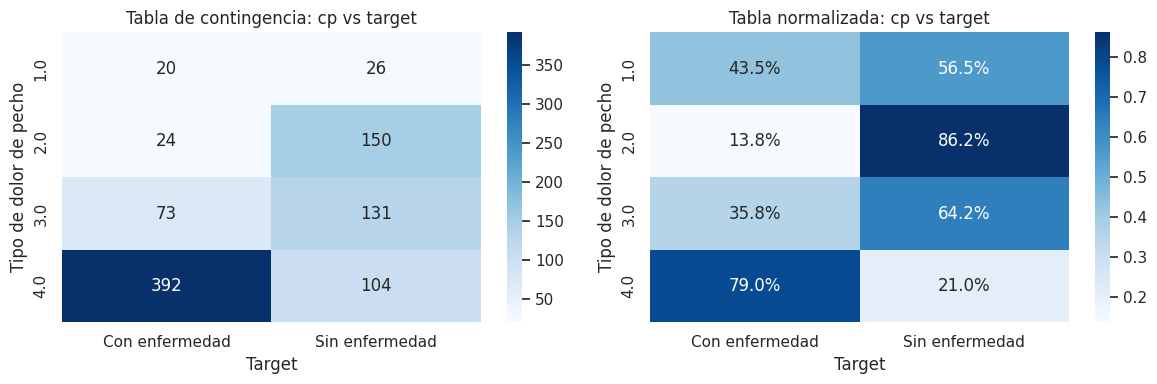

In [38]:
cross_tab2 = pd.crosstab(df['cp'], df['target'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.heatmap(cross_tab2, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Tabla de contingencia: cp vs target')
axes[0].set_xlabel('Target')
axes[0].set_ylabel('Tipo de dolor de pecho')

cross_tab2_pct = pd.crosstab(df['cp'], df['target'], normalize='index')
sns.heatmap(cross_tab2_pct, annot=True, fmt='.1%', cmap='Blues', ax=axes[1])
axes[1].set_title('Tabla normalizada: cp vs target')
axes[1].set_xlabel('Target')
axes[1].set_ylabel('Tipo de dolor de pecho')

plt.tight_layout()
plt.show()

### Relaciones numérica-categórica

#### Boxplots y violinplots: variables numéricas vs target

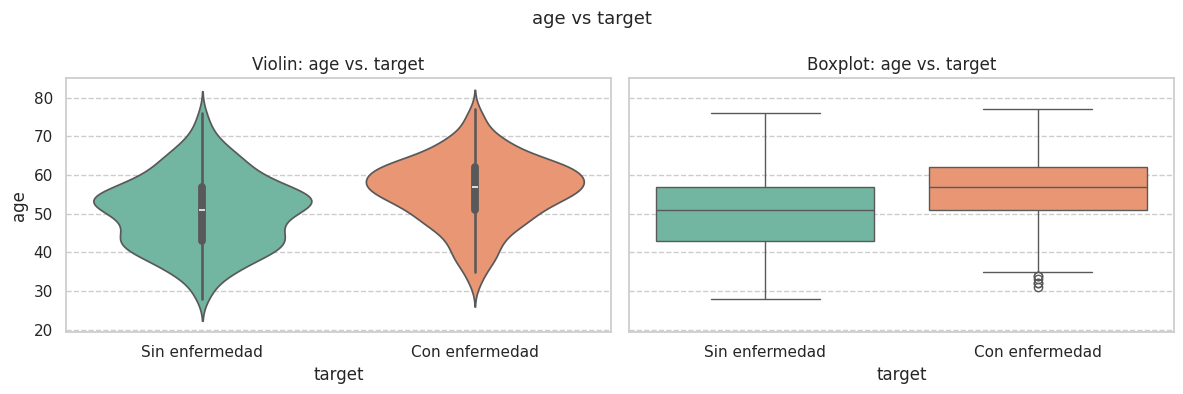

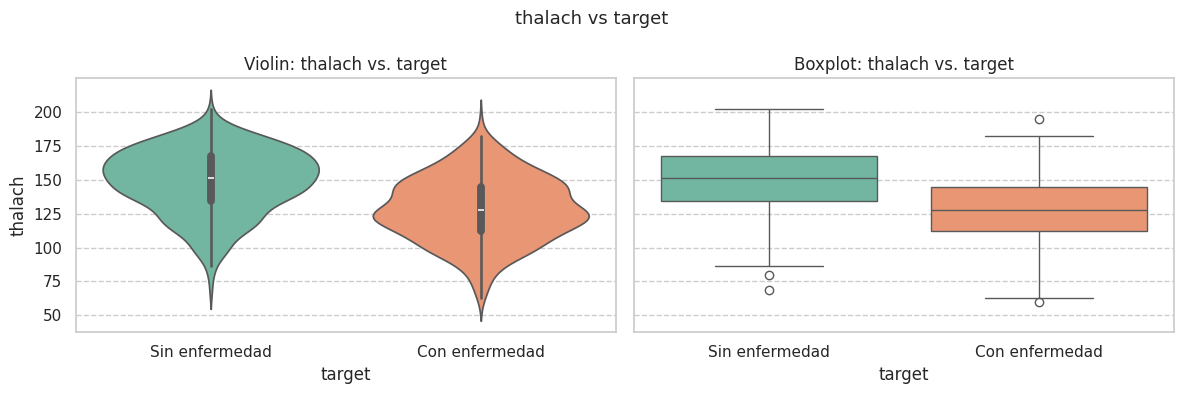

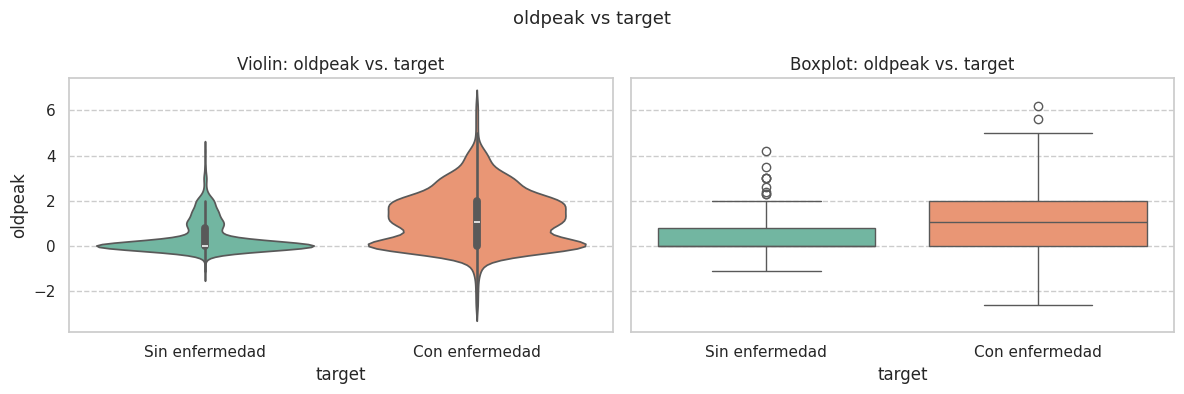

In [39]:
for num in ['age', 'thalach', 'oldpeak']:
    plot_violin_box(df, num, 'target', palette='Set2')

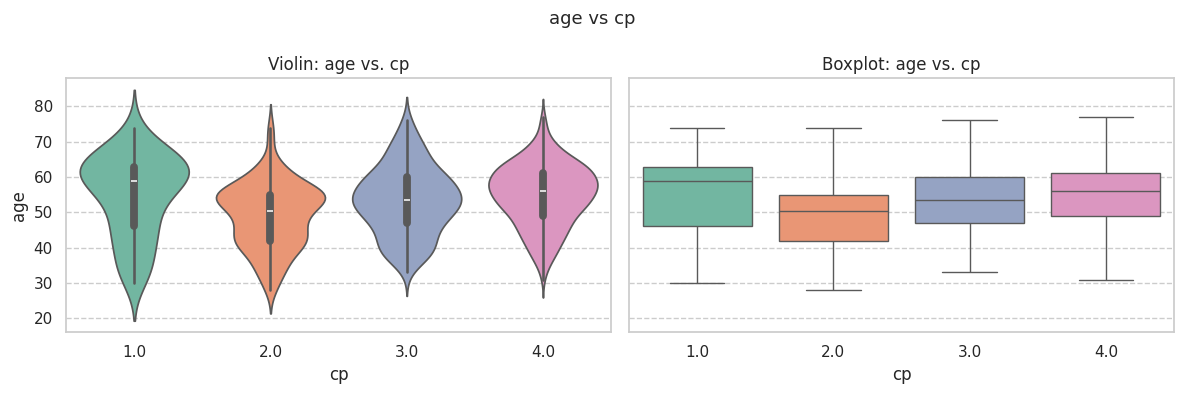

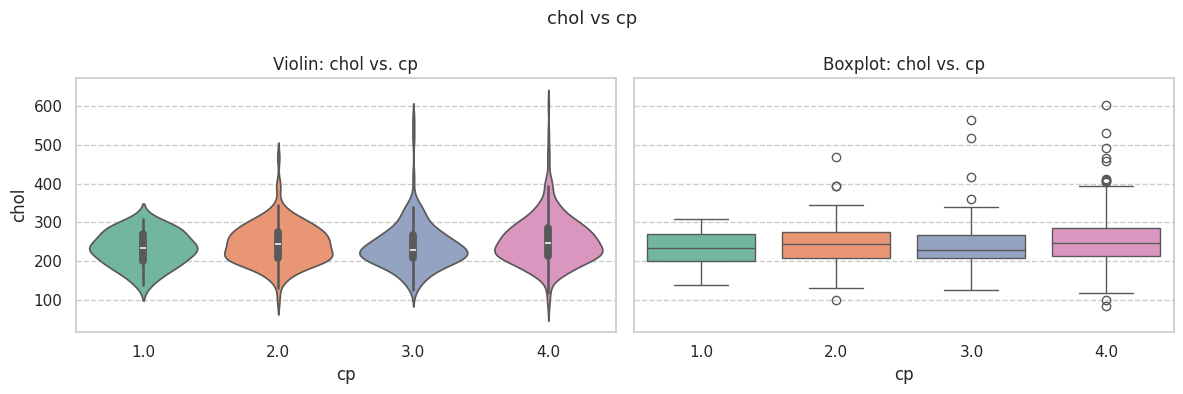

In [40]:
for num in ['age', 'chol']:
    plot_violin_box(df, num, 'cp', palette='Set2')

#### Stripplot y Swarmplot

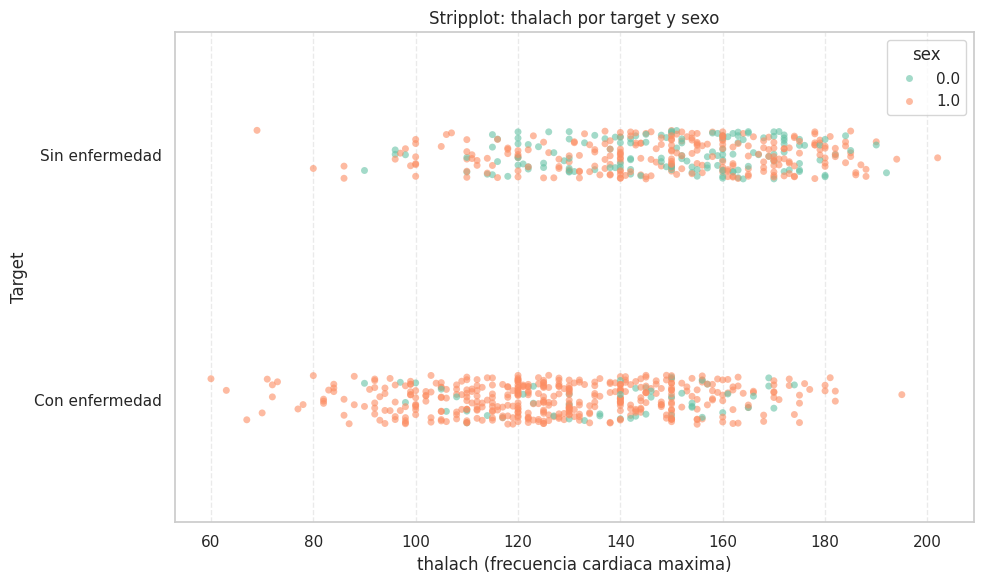

In [41]:
plt.figure(figsize=(10, 6))
sns.stripplot(data=df, x='thalach', y='target', 
              hue='sex', palette='Set2', alpha=0.6, size=5, jitter=True)
plt.title('Stripplot: thalach por target y sexo')
plt.xlabel('thalach (frecuencia cardiaca maxima)')
plt.ylabel('Target')
plt.grid(axis='x', ls='--', alpha=0.4)
plt.tight_layout()
plt.show()

### Promedios por grupo objetivo

In [42]:
resumen_objetivo = df.groupby("target")[["age", "trestbps", "chol", "thalach", "oldpeak"]].mean().round(2)

print("Promedios por grupo objetivo:")
resumen_objetivo

Promedios por grupo objetivo:


,age,trestbps,chol,thalach,oldpeak
target,,,,,
Con enfermedad,55.90,134.26,254.01,128.26,1.26
Sin enfermedad,50.55,129.91,240.16,148.80,0.42


## 9. Conclusiones

### Resumen de hallazgos principales:

1. **Dataset completo**: El dataset Heart Disease de UCI contiene 4 bases de datos (Cleveland, Hungary, Switzerland, Long Beach VA) con un total de 920+ registros y 14 variables utilizadas en experimentos publicados.

2. **Datos faltantes**: Las variables `ca` y `thal` presentan los porcentajes más altos de datos faltantes. Se recomienda:
   - Eliminar filas con muchos nulos
   - Imputar valores faltantes usando media, mediana o KNN

3. **Outliers**: Las variables `chol`, `trestbps` y `thalach` presentan valores atípicos que pueden afectar el análisis.

4. **Correlaciones**: Se observan correlaciones entre `age` y `trestbps`, y entre `oldpeak` y `slope`.

5. **Entropía**: La variable `thal` tiene alta entropía (diversidad de categorías), mientras que `sex` tiene baja entropía.

### Comparación con EDA anterior (`actividad_opcional2.ipynb`):

| Aspecto | EDA Anterior | EDA Completo |
|---------|--------------|--------------|
| **Dataset** | Solo Cleveland (303 filas) | Completo (920+ filas) |
| **Datos faltantes** | Solo porcentaje | Visualizaciones con `missingno` |
| **Outliers** | Boxplots básicos | Método IQR + Z-score |
| **Entropía** | No incluido | Calcula entropía de Shannon |
| **Correlaciones** | Básica | Más completa con máscara |